In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Accuracy: 0.8044692737430168
              precision    recall  f1-score   support

           0       0.80      0.89      0.84       105
           1       0.81      0.69      0.74        74

    accuracy                           0.80       179
   macro avg       0.81      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179

      Feature  Importance
1         Sex    0.448064
3        Fare    0.188921
0      Pclass    0.140964
2         Age    0.121642
4  FamilySize    0.081964
5     IsAlone    0.018445


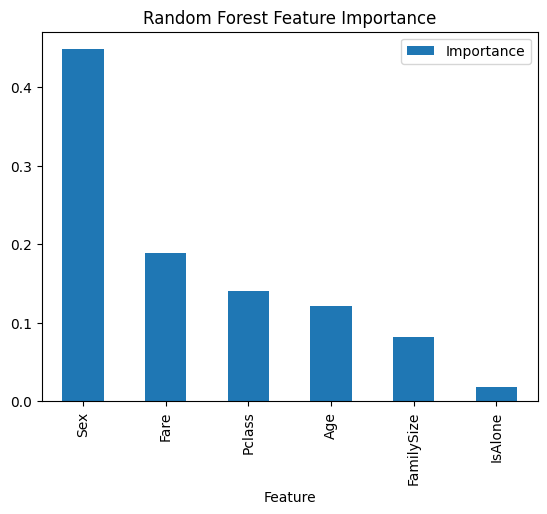

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import matplotlib.pyplot as plt

# Load and prepare Titanic
df = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

features = ["Pclass", "Sex", "Age", "Fare", "FamilySize", "IsAlone"]
X = df[features]
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Train Random Forest
model = RandomForestClassifier(
    n_estimators=100,  # 100 trees
    max_depth=5,
    random_state=42)
model.fit(X_train, y_train)

# Evaluate
predictions = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

# Feature Importance
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)
print(importance)
importance.plot(kind='bar', x='Feature', y='Importance')
plt.title("Random Forest Feature Importance")
plt.show()

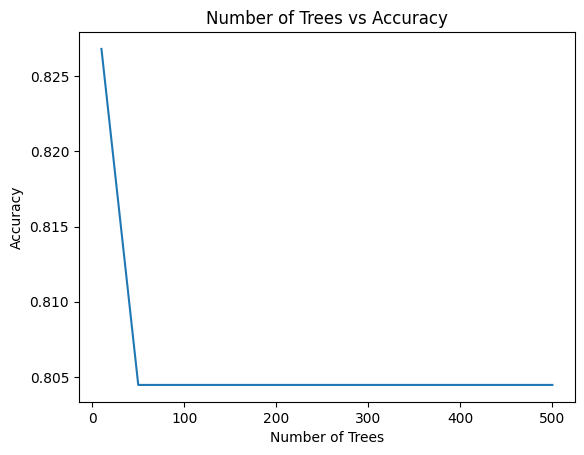

[(10, 0.8268156424581006), (50, 0.8044692737430168), (100, 0.8044692737430168), (200, 0.8044692737430168), (500, 0.8044692737430168)]


In [5]:
# Try different n_estimators
scores = []
trees = [10, 50, 100, 200, 500]

for n in trees:
    rf = RandomForestClassifier(n_estimators=n, 
                                max_depth=5, 
                                random_state=42)
    rf.fit(X_train, y_train)
    scores.append(accuracy_score(y_test, rf.predict(X_test)))

import matplotlib.pyplot as plt
plt.plot(trees, scores)
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Number of Trees vs Accuracy")
plt.show()

print(list(zip(trees, scores)))